# `add_embeddings` smoke walkthrough

End-to-end demo of `synth_setter.pipeline.data.add_embeddings`:

1. Build a tiny in-memory **Lance** dataset shaped like a `generate_dataset` /
   `finalize_dataset` shard (an `audio` tensor column plus `mel_spec` /
   `param_array`, with `ShardMetadata` embedded in the schema).
2. Run the **m2l + CLAP** add step. It appends:
   - `clap` — a `FixedSizeList<float32, 512>` LAION-CLAP embedding, **vector-
     searchable** (Lance builds an IVF_PQ index on it for large datasets).
   - `m2l` — a `fixed_shape_tensor<float32, (C*D, T)>` music2latent latent
     (retrievable, not a search vector).
3. Read the dataset back into a pandas `DataFrame` holding **just the params and
   the two new embedding columns**.
4. Run a **vector search** over the `clap` column with `nearest=`.

> Loading the real encoders downloads the music2latent and
> `laion/clap-htsat-unfused` checkpoints, so step 2 needs `music2latent`,
> `transformers`, and `torchaudio` installed and will pull weights on first run.

In [1]:
import tempfile
from pathlib import Path

import lance
import numpy as np
import pandas as pd

from synth_setter.data.vst.shapes import (
    AUDIO_FIELD,
    DATASET_FIELD_DTYPES,
    MEL_SPEC_FIELD,
    PARAM_ARRAY_FIELD,
    audio_dataset_shape,
    mel_dataset_shape,
    param_array_dataset_shape,
)
from synth_setter.pipeline.data.lance_shard import (
    lance_schema,
    read_shard_metadata,
    record_batch_from_arrays,
    write_lance_dataset,
)
from synth_setter.pipeline.schemas.shard_metadata import ShardMetadata

## 1. Build a smoke Lance dataset

Four rows of 1 s, 44.1 kHz stereo noise — the same on-disk layout a real shard
carries, including the `ShardMetadata` the add step reads the sample rate from.

In [2]:
rows, channels, sample_rate, duration, num_params = 4, 2, 44_100, 1.0, 56
shapes = {
    AUDIO_FIELD: audio_dataset_shape(rows, channels, sample_rate, duration),
    MEL_SPEC_FIELD: mel_dataset_shape(rows, channels, sample_rate, duration),
    PARAM_ARRAY_FIELD: param_array_dataset_shape(rows, num_params),
}
metadata = ShardMetadata(
    velocity=100,
    signal_duration_seconds=duration,
    sample_rate=sample_rate,
    channels=channels,
    min_loudness=-55.0,
)
schema = lance_schema(shapes, metadata)

rng = np.random.default_rng(0)
arrays = {
    AUDIO_FIELD: (0.1 * rng.standard_normal(shapes[AUDIO_FIELD])).astype(
        DATASET_FIELD_DTYPES[AUDIO_FIELD]
    ),
    MEL_SPEC_FIELD: np.zeros(shapes[MEL_SPEC_FIELD], DATASET_FIELD_DTYPES[MEL_SPEC_FIELD]),
    PARAM_ARRAY_FIELD: rng.random((rows, num_params)).astype(
        DATASET_FIELD_DTYPES[PARAM_ARRAY_FIELD]
    ),
}

uri = str(Path(tempfile.mkdtemp()) / "smoke.lance")
write_lance_dataset(uri, schema, [record_batch_from_arrays(arrays, schema)])
lance.dataset(uri).schema.names

[2026-06-17T00:19:54Z WARN  lance::dataset::write::insert] No existing dataset at /tmp/tmpxljfoidy/smoke.lance, it will be created


['audio', 'mel_spec', 'param_array']

## 2. Run the m2l + CLAP add step

`add_embeddings` reads only the `audio` column per batch and appends the `m2l`
tensor and `clap` vector columns. The sample rate comes from the shard metadata,
exactly as the `python -m synth_setter.pipeline.data.add_embeddings <uri>` CLI
does it.

We pass `build_index=False` here because IVF_PQ needs ~256 rows to train; on a
real (large) dataset keep the default so `clap` gets an ANN index. Exact
`nearest` search (step 4) works either way.

In [3]:
from synth_setter.pipeline.data.add_embeddings import (
    CLAP_FIELD,
    M2L_FIELD,
    add_embeddings,
    load_clap_audio_encoder,
    load_m2l_audio_encoder,
)

dataset = lance.dataset(uri)
sample_rate = int(read_shard_metadata(dataset.schema).sample_rate)

# First call downloads the music2latent + CLAP checkpoints.
m2l_encode = load_m2l_audio_encoder()
clap_encode = load_clap_audio_encoder()

add_embeddings(dataset, m2l_encode, clap_encode, sample_rate, build_index=False)
lance.dataset(uri).schema.to_string()

/home/build/synth-setter/.claude/worktrees/smoosense-nb-viz/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/build/synth-setter/.claude/worktrees/smoosense-nb-viz/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csr_array, issparse


2026-06-17 00:20:00 [info     ] loading_clap_checkpoint        checkpoint=laion/clap-htsat-unfused device=cuda


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 447/447 [00:00<00:00, 80611.14it/s]

'audio: extension<arrow.fixed_shape_tensor[value_type=halffloat, shape=[2,44100]]> not null\nmel_spec: extension<arrow.fixed_shape_tensor[value_type=float, shape=[2,128,101]]> not null\nparam_array: extension<arrow.fixed_shape_tensor[value_type=float, shape=[56]]> not null\nm2l: extension<arrow.fixed_shape_tensor[value_type=float, shape=[128,10], permutation=[0,1]]>\nclap: fixed_size_list<item: float>[512]\n  child 0, item: float\n-- schema metadata --\nsynth_setter.shard_metadata: \'{"velocity":100,"signal_duration_seconds":1\' + 97'

## 3. DataFrame of params + new embeddings

Project only `param_array`, `m2l`, and `clap`. `clap` rows come back as
fixed-size lists; `m2l` as a fixed-shape tensor.

In [4]:
table = lance.dataset(uri).to_table(columns=[PARAM_ARRAY_FIELD, M2L_FIELD, CLAP_FIELD])

frame = pd.DataFrame(
    {
        PARAM_ARRAY_FIELD: list(
            table.column(PARAM_ARRAY_FIELD).combine_chunks().to_numpy_ndarray()
        ),
        M2L_FIELD: list(table.column(M2L_FIELD).combine_chunks().to_numpy_ndarray()),
        CLAP_FIELD: [
            np.asarray(row, dtype=np.float32) for row in table.column(CLAP_FIELD).to_pylist()
        ],
    }
)
frame["m2l_shape"] = frame[M2L_FIELD].map(np.shape)
frame["clap_shape"] = frame[CLAP_FIELD].map(np.shape)
frame[["m2l_shape", "clap_shape"]]

,m2l_shape,clap_shape
0,"(128, 10)","(512,)"
1,"(128, 10)","(512,)"
2,"(128, 10)","(512,)"
3,"(128, 10)","(512,)"


## 4. Vector search over `clap`

Query the `clap` column with `nearest=`. Using row 0's own embedding as the
query, it should come back first (distance ~0). On a dataset with an IVF_PQ
index this is ANN; here (4 rows, no index) Lance falls back to an exact scan —
same API either way.

In [5]:
query = np.asarray(frame[CLAP_FIELD].iloc[0], dtype=np.float32)
neighbors = lance.dataset(uri).to_table(
    columns=[PARAM_ARRAY_FIELD],
    nearest={"column": CLAP_FIELD, "q": query, "k": 3},
)
neighbors.select(["_distance"]).to_pandas()

[2026-06-17T00:20:01Z WARN  lance::dataset::scanner] Deprecation warning, this behavior will change in the future. This search specified output columns but did not include `_distance`.  Currently the `_distance` column will be included.  In the future it will not.  Call `disable_scoring_autoprojection` to adopt the future behavior and avoid this warning


,_distance
0,0.000000
1,0.013890
2,0.016467


## 5. Browse the dataset in SmooSense

[SmooSense](https://smoosense.ai) renders a table as an interactive grid right
in the notebook with `Sense(df)` (per-column histograms, filters, sorting).

It **eagerly materializes every column**, so projecting the fixed-shape-tensor
columns (`audio`, `mel_spec`, `m2l`) or the 512-d `clap` vector blows up memory
— the same over-allocation that OOMs the DuckDB Table view on a full shard
([#1704](https://github.com/tinaudio/synth-setter/issues/1704)). Browse a
**narrow projection** instead: scalar params plus cheap per-row *summaries* of
the embeddings (shape, L2 norm), never the raw tensors.

SmooSense also renders **every row** it is handed, so cap large shards with `.head(N)` (a no-op on these four smoke rows).

> SmooSense isn't a project dependency — it needs Python ≥3.11 (above this repo's floor), so install it alongside the notebook with `pip install -U "smoosense[jupyter]"` ([#1681](https://github.com/tinaudio/synth-setter/issues/1681)).

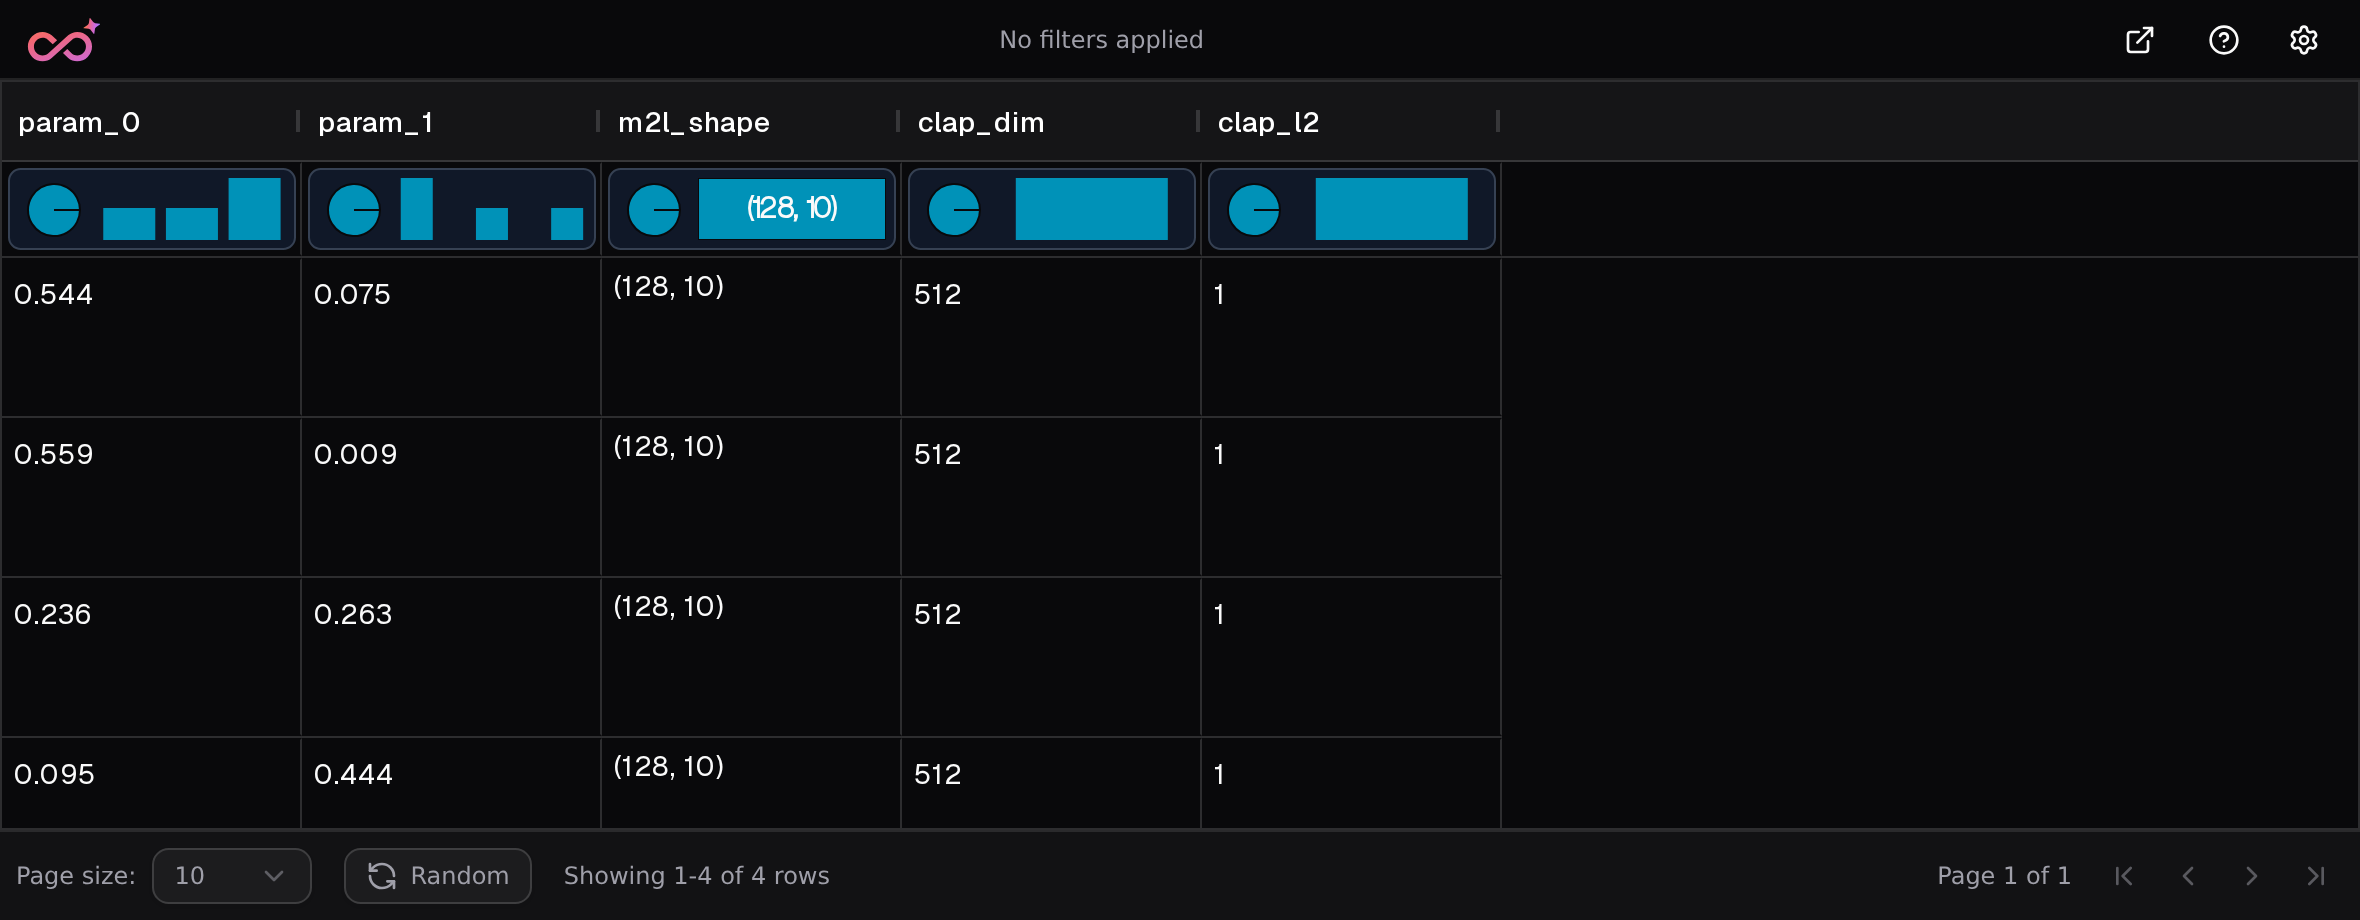

In [6]:
from smoosense.widget import Sense

# Scalar summaries only — the raw m2l/clap tensors would make SmooSense
# materialize every cell (#1704). `.head()` caps rows too: it renders every row
# it is handed, so cap large shards (a no-op on these 4 smoke rows).
view = pd.DataFrame(
    {
        "param_0": frame[PARAM_ARRAY_FIELD].map(lambda p: round(float(p[0]), 4)),
        "param_1": frame[PARAM_ARRAY_FIELD].map(lambda p: round(float(p[1]), 4)),
        "m2l_shape": frame["m2l_shape"].astype(str),
        "clap_dim": frame[CLAP_FIELD].map(lambda c: int(np.shape(c)[0])),
        "clap_l2": frame[CLAP_FIELD].map(lambda c: round(float(np.linalg.norm(c)), 4)),
    }
).head(64)
Sense(view)